# Data Analysis

This notebook analyzes the final interview dataset produced by the dataset-construction pipeline.

We first examine how well the interview sample represents the broader set of eligible player-tournament observations, and then inspect the prediction-target distribution and the main representation differences relevant to the subsequent stages of the project.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name == "data_code":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

FINAL_DATASET = PROCESSED_DATA_DIR / "player_tournament_interview_dataset.csv"

PREV3_FULL_DATASET_FILE = PROCESSED_DATA_DIR / "player_tournament_interview_features_with_prev3_history.csv"

## Dataset Representation and Selection Bias

The availability of pre-tournament interviews may not be uniform across players and tournaments. We therefore compare the final interview dataset with the broader set of eligible player-tournament observations for which at least three previous tournaments are available.

This comparison is used to identify potential representation differences in player ranking, player frequency, tour, year, surface, tournament level, age, tournament participation, season, and tournament progression.

DATASETS LOADED
Eligible observations: (27993, 76)
Interview observations: (830, 58)

Unique players - eligible observations: 747
Unique players - interview observations: 147

Unique tournaments - eligible observations: 174
Unique tournaments - interview observations: 38

PLAYER RANKING

Eligible observations:
count    27961.000000
mean        77.255999
std         86.786599
min          1.000000
25%         32.000000
50%         61.000000
75%         95.000000
max       1556.000000
Name: player_rank, dtype: float64

Interview observations:
count     826.000000
mean       37.602906
std       105.462317
min         1.000000
25%         3.000000
50%         7.000000
75%        26.750000
max      1250.000000
Name: player_rank, dtype: float64


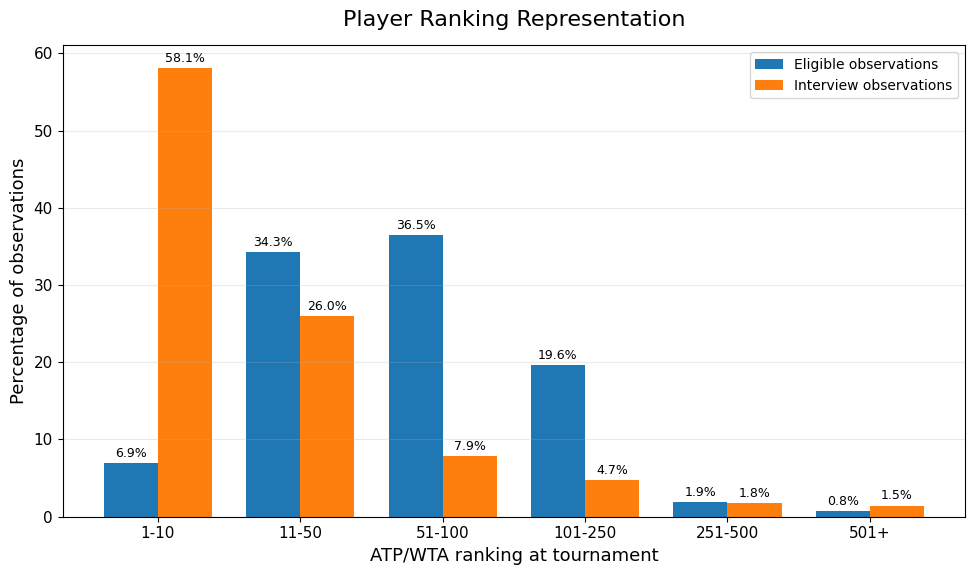

,Eligible observations (%),Interview observations (%),Difference (percentage points)
player_rank,,,
1-10,6.89,58.11,51.22
11-50,34.30,26.03,-8.27
51-100,36.47,7.87,-28.60
101-250,19.65,4.72,-14.93
251-500,1.93,1.82,-0.12
501+,0.76,1.45,0.69


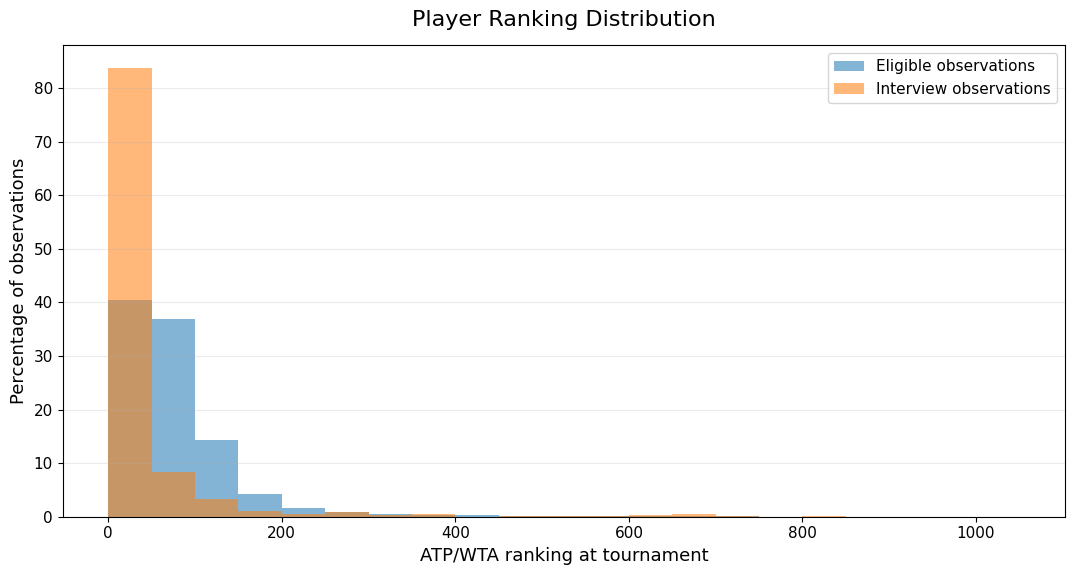


PLAYER REPRESENTATION
count    147.000000
mean       5.646259
std        8.063789
min        1.000000
25%        1.000000
50%        2.000000
75%        6.500000
max       44.000000
Name: count, dtype: float64


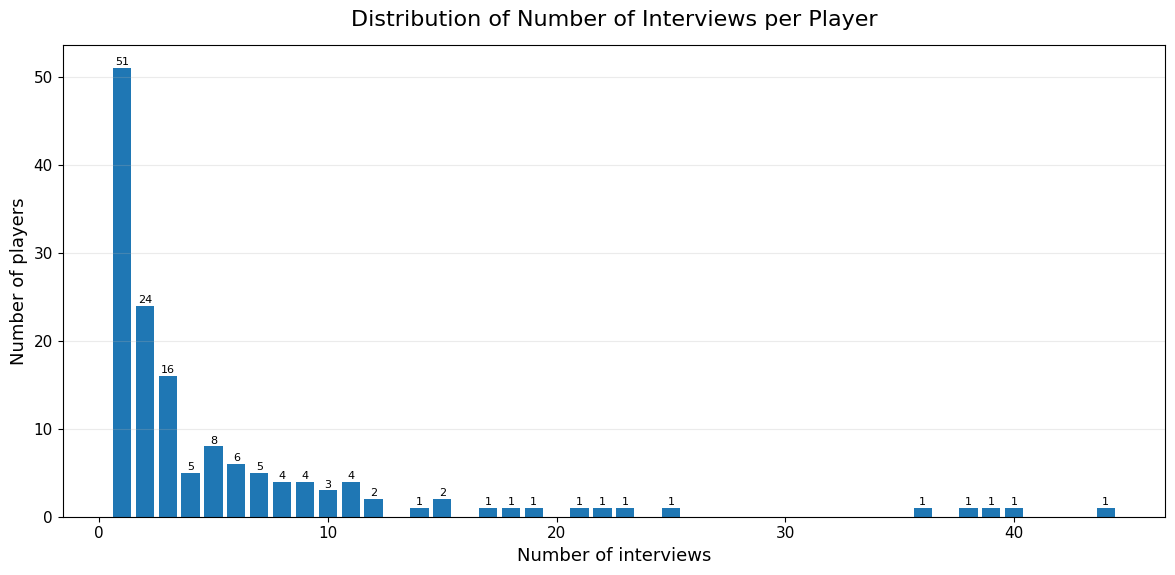

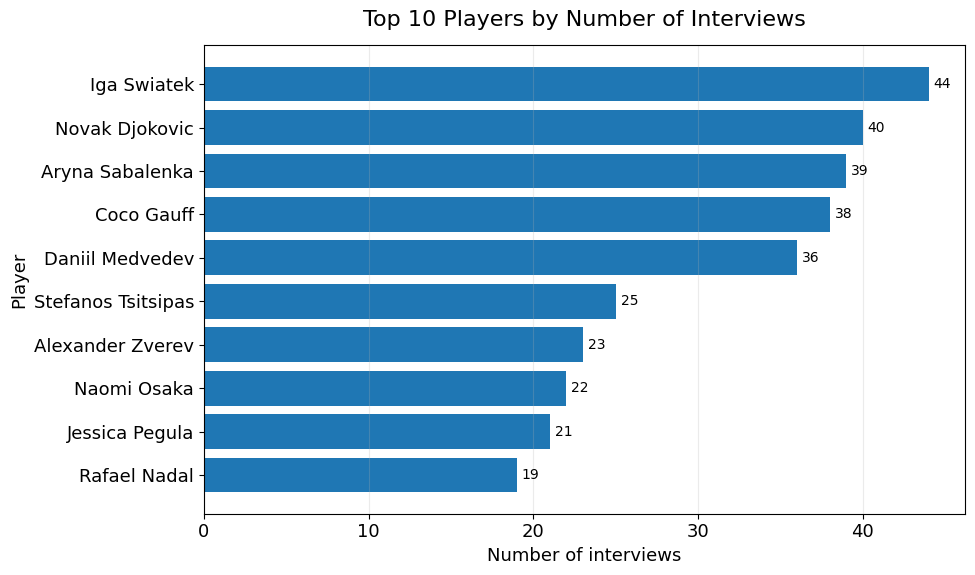

Top 10 players account for 36.99% of all interviews.


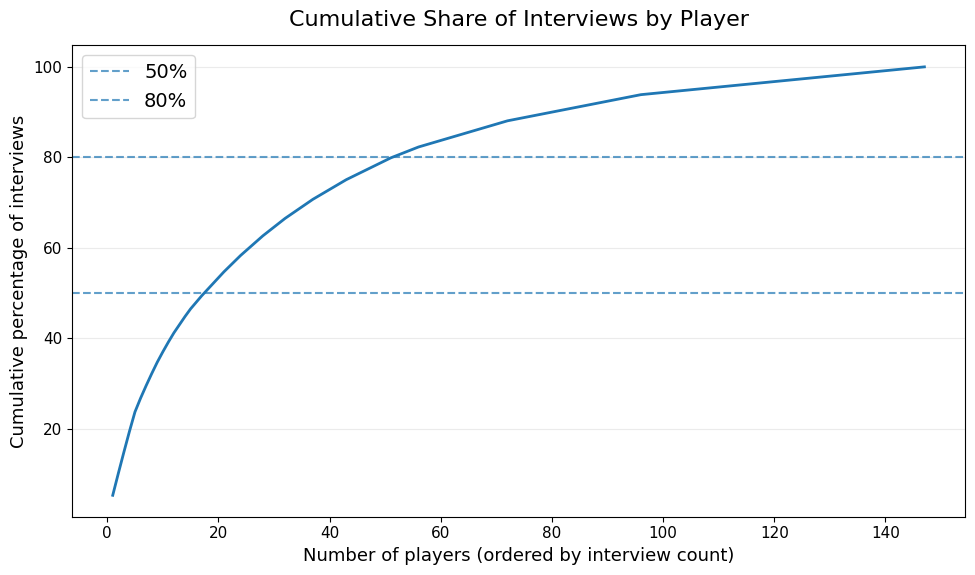

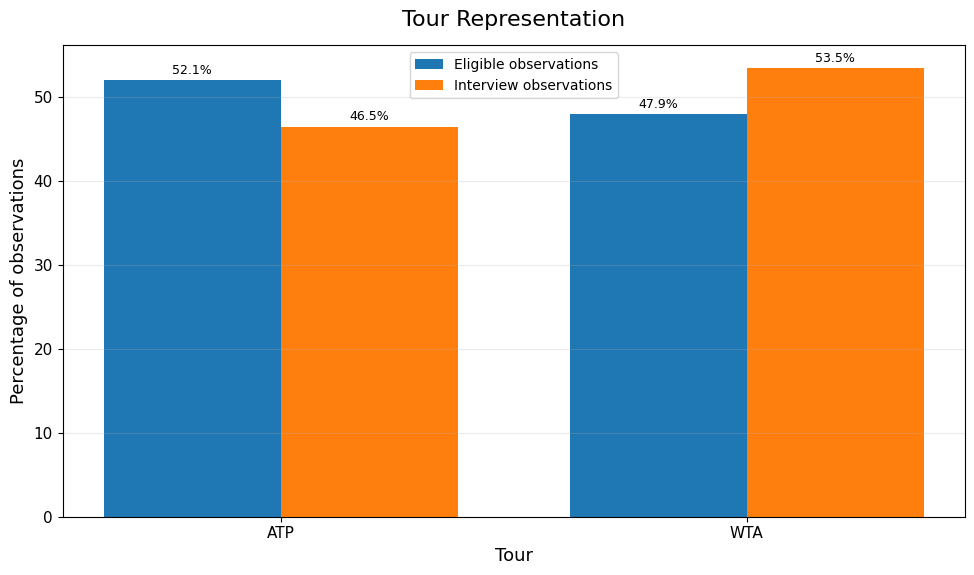

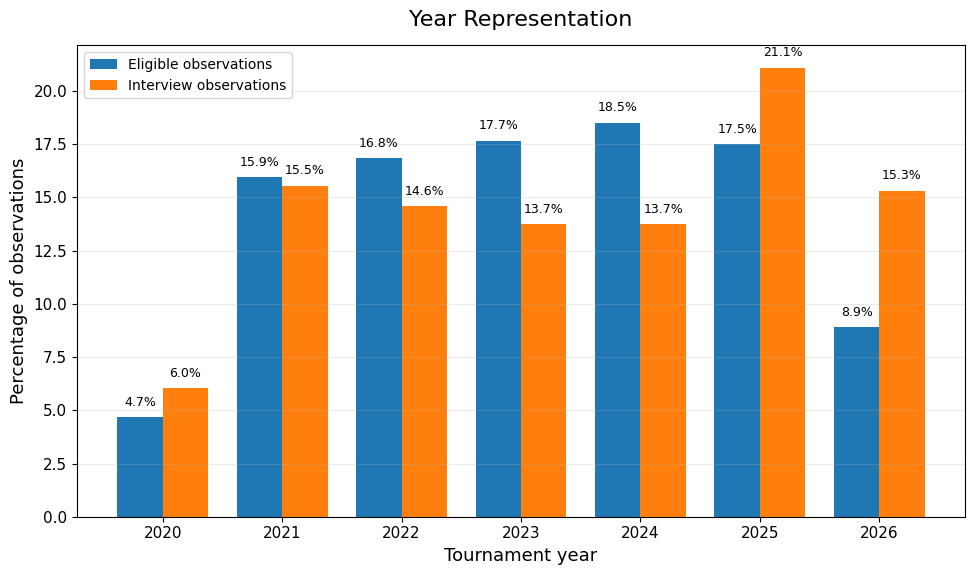

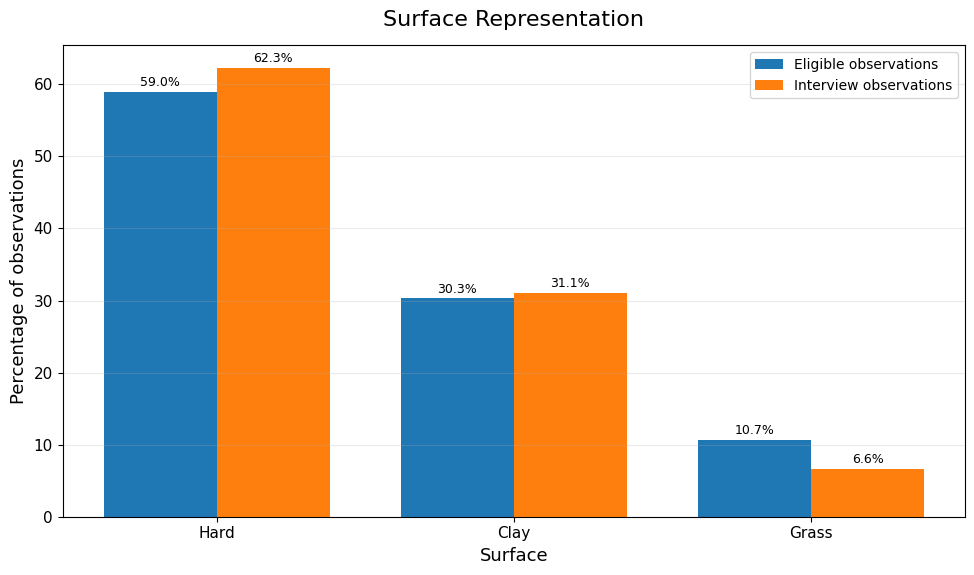

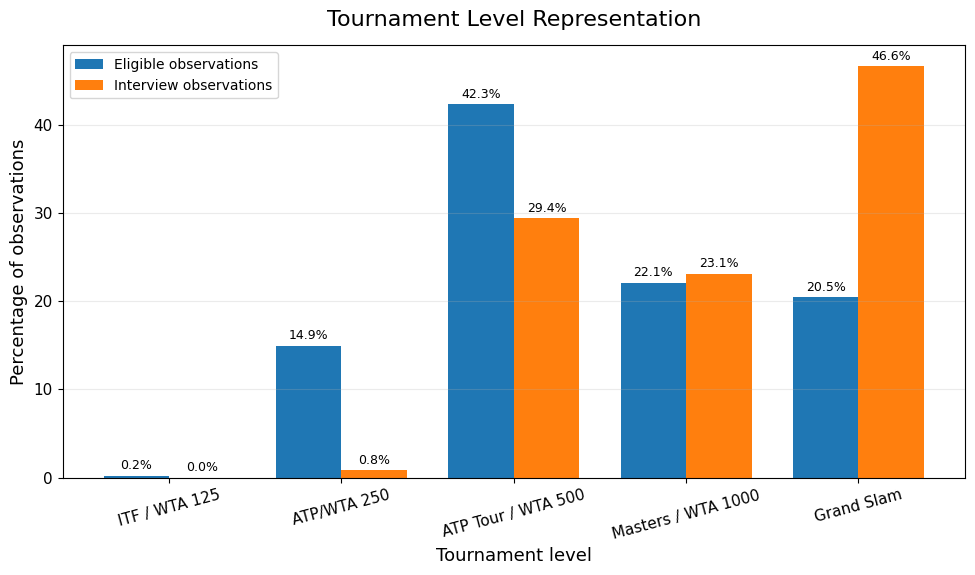

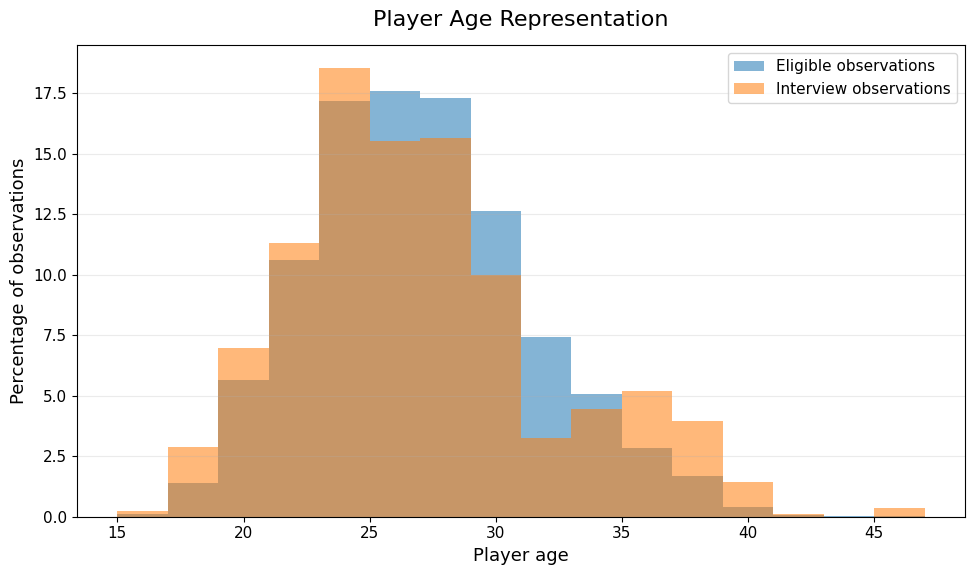

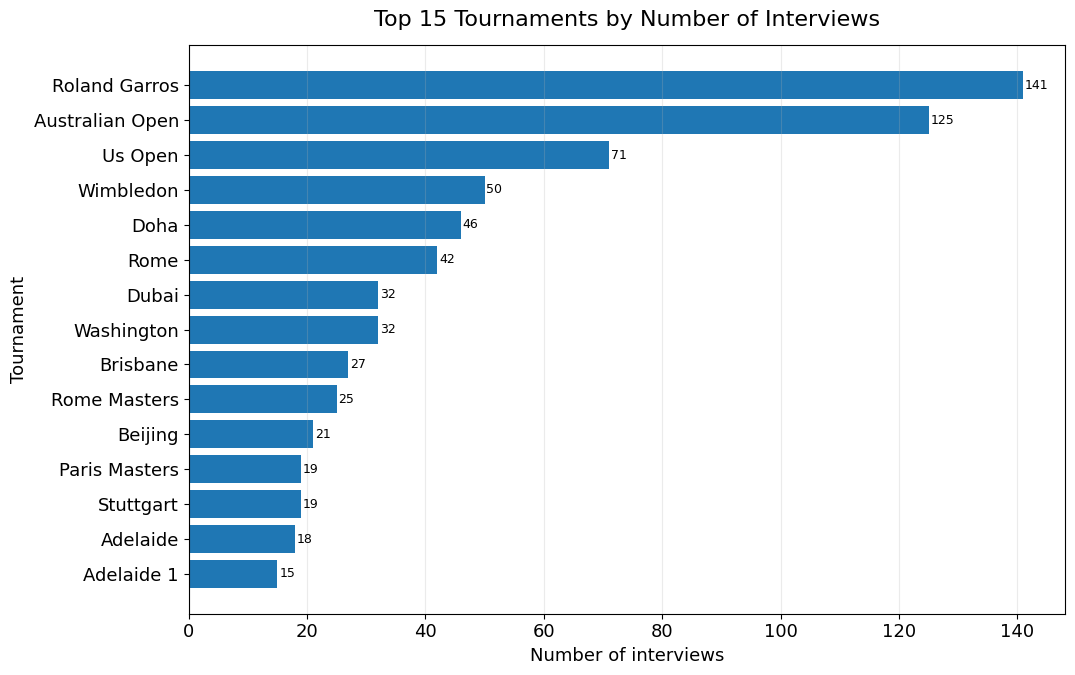

In [13]:
# ============================================================
# Dataset Representation and Selection Bias Analysis
# Compare eligible player-tournament observations
# with final interview observations
# ============================================================

# ------------------------------------------------------------
# Eligible observations: PREV3_FULL_DATASET_FILE
# player-tournament rows after feature engineering,
# before filtering to observations with interviews
# ------------------------------------------------------------
population_df = pd.read_csv(
    PREV3_FULL_DATASET_FILE,
    parse_dates=["tourney_date"],
    low_memory=False
)

population_df = (
    population_df[
        population_df["num_previous_tournaments"] >= 3
    ]
    .copy()
)

# ------------------------------------------------------------
# Final interview observations
# ------------------------------------------------------------
interviews_df = pd.read_csv(
    FINAL_DATASET,
    parse_dates=[
        "tourney_date",
        "first_pre_match_interview_date",
    ],
    low_memory=False
)

print("=" * 70)
print("DATASETS LOADED")
print("=" * 70)

print(
    "Eligible observations:",
    population_df.shape
)

print(
    "Interview observations:",
    interviews_df.shape
)

print(
    "\nUnique players - eligible observations:",
    population_df["player_name"].nunique()
)

print(
    "Unique players - interview observations:",
    interviews_df["player_name"].nunique()
)

print(
    "\nUnique tournaments - eligible observations:",
    population_df["tourney_name"].nunique()
)

print(
    "Unique tournaments - interview observations:",
    interviews_df["tourney_name"].nunique()
)


# ============================================================
# 2. Plot settings
# ============================================================

TITLE_SIZE = 16
LABEL_SIZE = 13
TICK_SIZE = 11


def finish_plot(
    title,
    xlabel,
    ylabel,
    rotation=0
):

    plt.title(
        title,
        fontsize=TITLE_SIZE,
        pad=14
    )

    plt.xlabel(
        xlabel,
        fontsize=LABEL_SIZE
    )

    plt.ylabel(
        ylabel,
        fontsize=LABEL_SIZE
    )

    plt.xticks(
        fontsize=TICK_SIZE,
        rotation=rotation
    )

    plt.yticks(
        fontsize=TICK_SIZE
    )

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()


def plot_percentage_comparison(
    population_pct,
    interview_pct,
    title,
    xlabel,
    rotation=0
):

    categories = population_pct.index

    x = np.arange(
        len(categories)
    )

    width = 0.38

    plt.figure(
        figsize=(10, 6)
    )

    bars1 = plt.bar(
        x - width / 2,
        population_pct.values,
        width,
        label="Eligible observations"
    )

    bars2 = plt.bar(
        x + width / 2,
        interview_pct.values,
        width,
        label="Interview observations"
    )

    plt.xticks(
        x,
        categories,
        rotation=rotation
    )

    for bars in [
        bars1,
        bars2
    ]:

        for bar in bars:

            height = (
                bar.get_height()
            )

            plt.text(
                bar.get_x()
                + bar.get_width() / 2,
                height + 0.4,
                f"{height:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.legend(
        fontsize=10
    )

    finish_plot(
        title=title,
        xlabel=xlabel,
        ylabel="Percentage of observations",
        rotation=rotation
    )


# ============================================================
# 3. PLAYER RANKING
# ============================================================

population_rank = (
    pd.to_numeric(
        population_df["player_rank"],
        errors="coerce"
    )
)

interview_rank = (
    pd.to_numeric(
        interviews_df["player_rank"],
        errors="coerce"
    )
)


# Ignore missing ranks encoded as -1
population_rank = (
    population_rank[
        population_rank > 0
    ]
)

interview_rank = (
    interview_rank[
        interview_rank > 0
    ]
)


print("\n" + "=" * 70)
print("PLAYER RANKING")
print("=" * 70)

print("\nEligible observations:")
print(
    population_rank.describe()
)

print("\nInterview observations:")
print(
    interview_rank.describe()
)


# ============================================================
# 3A. Rank group comparison
# ============================================================

RANK_BINS = [
    0,
    10,
    50,
    100,
    250,
    500,
    np.inf
]

RANK_LABELS = [
    "1-10",
    "11-50",
    "51-100",
    "101-250",
    "251-500",
    "501+"
]


def get_rank_distribution(
    rank_series
):

    groups = pd.cut(
        rank_series,
        bins=RANK_BINS,
        labels=RANK_LABELS,
        include_lowest=True
    )

    return (
        groups
        .value_counts(
            normalize=True
        )
        .reindex(
            RANK_LABELS,
            fill_value=0
        )
        * 100
    )


population_rank_pct = (
    get_rank_distribution(
        population_rank
    )
)

interview_rank_pct = (
    get_rank_distribution(
        interview_rank
    )
)


plot_percentage_comparison(
    population_rank_pct,
    interview_rank_pct,
    title="Player Ranking Representation",
    xlabel="ATP/WTA ranking at tournament"
)


rank_comparison_df = pd.DataFrame(
    {
        "Eligible observations (%)":
            population_rank_pct.round(2),

        "Interview observations (%)":
            interview_rank_pct.round(2),

        "Difference (percentage points)":
            (
                interview_rank_pct
                - population_rank_pct
            ).round(2)
    }
)

display(
    rank_comparison_df
)


# ============================================================
# 3B. Rank histogram comparison
# ============================================================

MAX_RANK_FOR_PLOT = 1000

population_rank_plot = (
    population_rank[
        population_rank
        <= MAX_RANK_FOR_PLOT
    ]
)

interview_rank_plot = (
    interview_rank[
        interview_rank
        <= MAX_RANK_FOR_PLOT
    ]
)

bins = np.arange(
    0,
    MAX_RANK_FOR_PLOT + 51,
    50
)

plt.figure(
    figsize=(11, 6)
)

plt.hist(
    population_rank_plot,
    bins=bins,
    weights=(
        np.ones(
            len(population_rank_plot)
        )
        / len(population_rank_plot)
        * 100
    ),
    alpha=0.55,
    label="Eligible observations"
)

plt.hist(
    interview_rank_plot,
    bins=bins,
    weights=(
        np.ones(
            len(interview_rank_plot)
        )
        / len(interview_rank_plot)
        * 100
    ),
    alpha=0.55,
    label="Interview observations"
)

plt.legend(
    fontsize=11
)

finish_plot(
    title="Player Ranking Distribution",
    xlabel="ATP/WTA ranking at tournament",
    ylabel="Percentage of observations"
)


# ============================================================
# 4. PLAYER REPRESENTATION
# Final interview observations only
# ============================================================

interviews_per_player = (
    interviews_df[
        "player_name"
    ]
    .value_counts()
)


print("\n" + "=" * 70)
print("PLAYER REPRESENTATION")
print("=" * 70)

print(
    interviews_per_player.describe()
)


# ============================================================
# 4A. Distribution of interviews per player
# ============================================================

distribution = (
    interviews_per_player
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    distribution.index,
    distribution.values
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        height + 0.3,
        str(
            int(height)
        ),
        ha="center",
        fontsize=8
    )

finish_plot(
    title=(
        "Distribution of Number "
        "of Interviews per Player"
    ),
    xlabel="Number of interviews",
    ylabel="Number of players"
)


# ============================================================
# 4B. Top 10 players
# ============================================================

top10_players = (
    interviews_per_player
    .head(10)
    .sort_values()
)

top10_share = (
    top10_players.sum()
    / len(interviews_df)
    * 100
)

plt.figure(
    figsize=(10, 6)
)

bars = plt.barh(
    top10_players.index,
    top10_players.values
)

for bar in bars:

    width = (
        bar.get_width()
    )

    plt.text(
        width + 0.3,
        bar.get_y()
        + bar.get_height() / 2,
        str(
            int(width)
        ),
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Players by Number of Interviews",
    fontsize=TITLE_SIZE,
    pad=14
)

plt.xlabel(
    "Number of interviews",
    fontsize=LABEL_SIZE
)

plt.ylabel(
    "Player",
    fontsize=LABEL_SIZE
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()


print(
    f"Top 10 players account for "
    f"{top10_share:.2f}% "
    f"of all interviews."
)


# ============================================================
# 4C. Cumulative player concentration
# ============================================================

sorted_counts = (
    interviews_per_player
    .sort_values(
        ascending=False
    )
)

cumulative_pct = (
    sorted_counts.cumsum()
    / sorted_counts.sum()
    * 100
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    np.arange(
        1,
        len(cumulative_pct) + 1
    ),
    cumulative_pct,
    linewidth=2
)

plt.axhline(
    50,
    linestyle="--",
    alpha=0.7,
    label="50%"
)

plt.axhline(
    80,
    linestyle="--",
    alpha=0.7,
    label="80%"
)

plt.legend()

finish_plot(
    title=(
        "Cumulative Share of "
        "Interviews by Player"
    ),
    xlabel=(
        "Number of players "
        "(ordered by interview count)"
    ),
    ylabel=(
        "Cumulative percentage "
        "of interviews"
    )
)


# ============================================================
# 5. ATP / WTA
# ============================================================

population_tour = (
    population_df[
        "is_male"
    ]
    .map(
        {
            1: "ATP",
            0: "WTA"
        }
    )
    .value_counts(
        normalize=True
    )
    .reindex(
        [
            "ATP",
            "WTA"
        ],
        fill_value=0
    )
    * 100
)

interview_tour = (
    interviews_df[
        "is_male"
    ]
    .map(
        {
            1: "ATP",
            0: "WTA"
        }
    )
    .value_counts(
        normalize=True
    )
    .reindex(
        [
            "ATP",
            "WTA"
        ],
        fill_value=0
    )
    * 100
)


plot_percentage_comparison(
    population_tour,
    interview_tour,
    title="Tour Representation",
    xlabel="Tour"
)


# ============================================================
# 6. YEAR
# ============================================================

YEARS = list(
    range(
        2020,
        2027
    )
)

population_year = (
    population_df[
        "tourney_year"
    ]
    .value_counts(
        normalize=True
    )
    .reindex(
        YEARS,
        fill_value=0
    )
    * 100
)

interview_year = (
    interviews_df[
        "tourney_year"
    ]
    .value_counts(
        normalize=True
    )
    .reindex(
        YEARS,
        fill_value=0
    )
    * 100
)


plot_percentage_comparison(
    population_year,
    interview_year,
    title="Year Representation",
    xlabel="Tournament year"
)


# ============================================================
# 7. SURFACE
# ============================================================

def get_surface(
    df
):

    return np.select(
        [
            df["is_hard_surface"] == 1,
            df["is_clay_surface"] == 1
        ],
        [
            "Hard",
            "Clay"
        ],
        default="Grass"
    )


population_surface_label = (
    get_surface(
        population_df
    )
)

interview_surface_label = (
    get_surface(
        interviews_df
    )
)


SURFACE_ORDER = [
    "Hard",
    "Clay",
    "Grass"
]


population_surface = (
    pd.Series(
        population_surface_label
    )
    .value_counts(
        normalize=True
    )
    .reindex(
        SURFACE_ORDER,
        fill_value=0
    )
    * 100
)

interview_surface = (
    pd.Series(
        interview_surface_label
    )
    .value_counts(
        normalize=True
    )
    .reindex(
        SURFACE_ORDER,
        fill_value=0
    )
    * 100
)


plot_percentage_comparison(
    population_surface,
    interview_surface,
    title="Surface Representation",
    xlabel="Surface"
)


# ============================================================
# 8. TOURNAMENT LEVEL
# ============================================================

LEVEL_ORDER = [
    0,
    1,
    2,
    3,
    4
]

LEVEL_LABELS = {
    0: "ITF / WTA 125",
    1: "ATP/WTA 250",
    2: "ATP Tour / WTA 500",
    3: "Masters / WTA 1000",
    4: "Grand Slam"
}


population_level = (
    population_df[
        "tournament_level_score"
    ]
    .value_counts(
        normalize=True
    )
    .reindex(
        LEVEL_ORDER,
        fill_value=0
    )
    * 100
)

interview_level = (
    interviews_df[
        "tournament_level_score"
    ]
    .value_counts(
        normalize=True
    )
    .reindex(
        LEVEL_ORDER,
        fill_value=0
    )
    * 100
)


population_level.index = [
    LEVEL_LABELS[x]
    for x in population_level.index
]

interview_level.index = [
    LEVEL_LABELS[x]
    for x in interview_level.index
]


plot_percentage_comparison(
    population_level,
    interview_level,
    title="Tournament Level Representation",
    xlabel="Tournament level",
    rotation=15
)


# ============================================================
# 9. PLAYER AGE
# ============================================================

population_age = (
    pd.to_numeric(
        population_df[
            "player_age"
        ],
        errors="coerce"
    )
    .dropna()
)

interview_age = (
    pd.to_numeric(
        interviews_df[
            "player_age"
        ],
        errors="coerce"
    )
    .dropna()
)

bins = np.arange(
    15,
    48,
    2
)

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    population_age,
    bins=bins,
    weights=(
        np.ones(
            len(population_age)
        )
        / len(population_age)
        * 100
    ),
    alpha=0.55,
    label="Eligible observations"
)

plt.hist(
    interview_age,
    bins=bins,
    weights=(
        np.ones(
            len(interview_age)
        )
        / len(interview_age)
        * 100
    ),
    alpha=0.55,
    label="Interview observations"
)

plt.legend(
    fontsize=11
)

finish_plot(
    title="Player Age Representation",
    xlabel="Player age",
    ylabel="Percentage of observations"
)


# ============================================================
# 10. TOURNAMENT REPRESENTATION
# Final interview observations only
# ============================================================

tournament_counts = (
    interviews_df[
        "tourney_name"
    ]
    .value_counts()
)

top15_tournaments = (
    tournament_counts
    .head(15)
    .sort_values()
)

plt.figure(
    figsize=(11, 7)
)

bars = plt.barh(
    top15_tournaments.index,
    top15_tournaments.values
)

for bar in bars:

    width = (
        bar.get_width()
    )

    plt.text(
        width + 0.3,
        bar.get_y()
        + bar.get_height() / 2,
        str(
            int(width)
        ),
        va="center",
        fontsize=9
    )

plt.title(
    "Top 15 Tournaments by Number of Interviews",
    fontsize=TITLE_SIZE,
    pad=14
)

plt.xlabel(
    "Number of interviews",
    fontsize=LABEL_SIZE
)

plt.ylabel(
    "Tournament",
    fontsize=LABEL_SIZE
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()


### Interview Sample Characteristics

The following distributions describe the structural characteristics of the interviews in the final dataset.

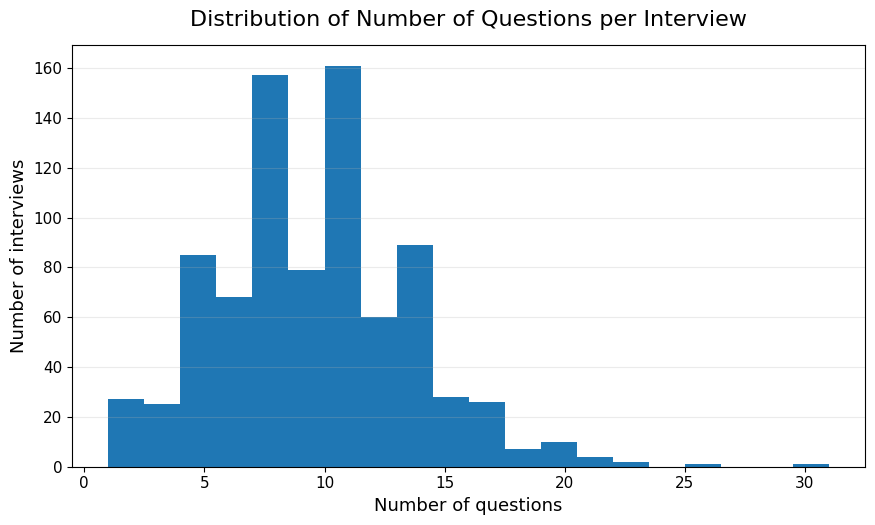

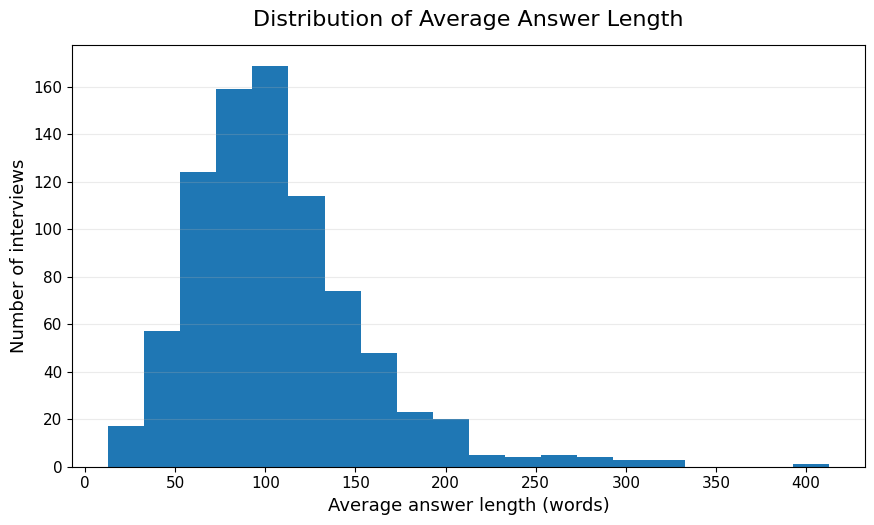

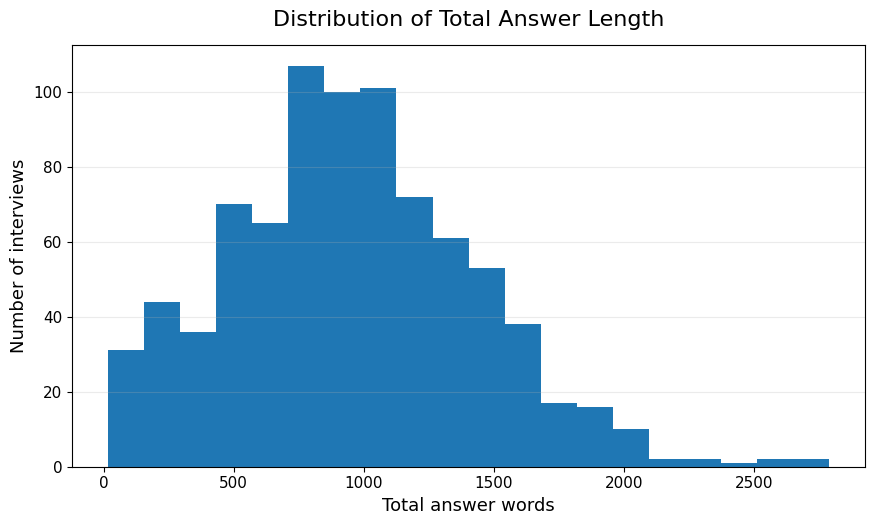

In [11]:

# ============================================================
# 11. INTERVIEW STRUCTURE
# Final interview observations only
# ============================================================

structure_features = [
    (
        "num_questions",
        "Distribution of Number of Questions per Interview",
        "Number of questions"
    ),
    (
        "avg_answer_length_words",
        "Distribution of Average Answer Length",
        "Average answer length (words)"
    ),
    (
        "total_answer_words",
        "Distribution of Total Answer Length",
        "Total answer words"
    ),
]


for (
    column,
    title,
    xlabel
) in structure_features:

    plt.figure(
        figsize=(9, 5.5)
    )

    plt.hist(
        interviews_df[
            column
        ].dropna(),
        bins=20
    )

    finish_plot(
        title=title,
        xlabel=xlabel,
        ylabel="Number of interviews"
    )


Summary

In [12]:
# ============================================================
# 12. Summary
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print(
    "Eligible observations:",
    len(population_df)
)

print(
    "Interview observations:",
    len(interviews_df)
)

print(
    "\nEligible unique players:",
    population_df[
        "player_name"
    ].nunique()
)

print(
    "Interview unique players:",
    interviews_df[
        "player_name"
    ].nunique()
)

print(
    "\nPlayers with exactly one interview:",
    int(
        (
            interviews_per_player
            == 1
        ).sum()
    )
)

print(
    "Players with at least 10 interviews:",
    int(
        (
            interviews_per_player
            >= 10
        ).sum()
    )
)

print(
    f"Top 10 players account for "
    f"{top10_share:.2f}% "
    f"of all interviews."
)


SUMMARY
Eligible observations: 27993
Interview observations: 830

Eligible unique players: 747
Interview unique players: 147

Players with exactly one interview: 51
Players with at least 10 interviews: 24
Top 10 players account for 36.99% of all interviews.


### Tournament Progression Representation

We compare tournament progression between the eligible observations and the interview observations to determine whether interviews are disproportionately available for players who advance further in tournaments.


TOURNAMENT PROGRESSION

Eligible observations:
count    27993.000000
mean         0.197154
std          0.240318
min          0.000000
25%          0.000000
50%          0.142857
75%          0.285714
max          1.000000
Name: tournament_finish_score, dtype: float64

Interview observations:
count    830.000000
mean       0.410379
std        0.317572
min        0.000000
25%        0.142857
50%        0.400000
75%        0.666667
max        1.000000
Name: tournament_finish_score, dtype: float64


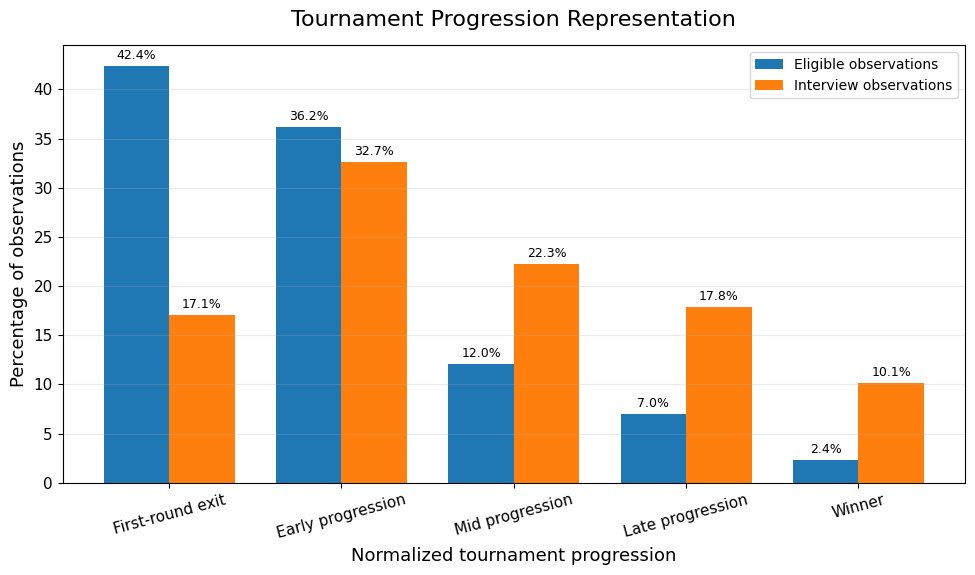

,Eligible observations (%),Interview observations (%),Difference (percentage points)
tournament_finish_score,,,
First-round exit,42.35,17.11,-25.25
Early progression,36.23,32.65,-3.58
Mid progression,12.05,22.29,10.24
Late progression,7.01,17.83,10.82
Winner,2.36,10.12,7.76


In [9]:
# ============================================================
# TOURNAMENT PROGRESSION
# ============================================================

population_finish = pd.to_numeric(
    population_df["tournament_finish_score"],
    errors="coerce"
).dropna()

interview_finish = pd.to_numeric(
    interviews_df["tournament_finish_score"],
    errors="coerce"
).dropna()


print("\n" + "=" * 70)
print("TOURNAMENT PROGRESSION")
print("=" * 70)

print("\nEligible observations:")
print(population_finish.describe())

print("\nInterview observations:")
print(interview_finish.describe())


# ------------------------------------------------------------
# Group normalized finish score into the same progression
# categories used in the final summary visualization
# ------------------------------------------------------------

PROGRESSION_LABELS = [
    "First-round exit",
    "Early progression",
    "Mid progression",
    "Late progression",
    "Winner",
]


def progression_category(score):

    if pd.isna(score):
        return np.nan

    if np.isclose(score, 0):
        return "First-round exit"

    if score < 0.4:
        return "Early progression"

    if score < 0.6:
        return "Mid progression"

    if score < 1:
        return "Late progression"

    return "Winner"


def get_finish_distribution(finish_series):

    groups = finish_series.apply(
        progression_category
    )

    return (
        groups
        .value_counts(normalize=True)
        .reindex(
            PROGRESSION_LABELS,
            fill_value=0
        )
        * 100
    )

population_finish_pct = get_finish_distribution(
    population_finish
)

interview_finish_pct = get_finish_distribution(
    interview_finish
)


plot_percentage_comparison(
    population_finish_pct,
    interview_finish_pct,
    title=(
        "Tournament Progression Representation"
    ),
    xlabel="Normalized tournament progression",
    rotation=15
)


finish_comparison_df = pd.DataFrame(
    {
        "Eligible observations (%)":
            population_finish_pct.round(2),

        "Interview observations (%)":
            interview_finish_pct.round(2),

        "Difference (percentage points)":
            (
                interview_finish_pct
                - population_finish_pct
            ).round(2)
    }
)

display(finish_comparison_df)

In [4]:
comparison = pd.DataFrame({
    "Eligible observations": [
        population_finish.mean(),
        population_finish.median(),
        (population_finish == 0).mean() * 100,
        (population_finish == 1).mean() * 100
    ],
    "Interview observations": [
        interview_finish.mean(),
        interview_finish.median(),
        (interview_finish == 0).mean() * 100,
        (interview_finish == 1).mean() * 100
    ]
}, index=[
    "Mean finish score",
    "Median finish score",
    "First-round exits (%)",
    "Tournament winners (%)"
])

display(comparison.round(2))

,Eligible observations,Interview observations
Mean finish score,0.20,0.41
Median finish score,0.14,0.40
First-round exits (%),42.35,17.11
Tournament winners (%),2.36,10.12


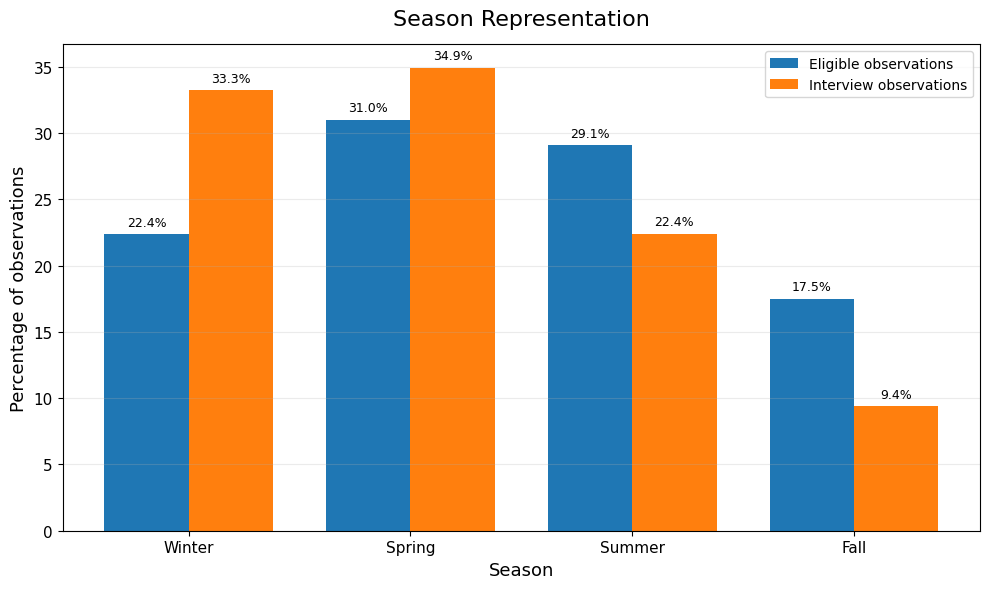

In [5]:
# ============================================================
# Season representation
# ============================================================

def get_season(df):

    return np.select(
        [
            df["is_winter"] == 1,
            df["is_spring"] == 1,
            df["is_summer"] == 1,
        ],
        [
            "Winter",
            "Spring",
            "Summer",
        ],
        default="Fall",
    )


population_season = (
    pd.Series(
        get_season(population_df)
    )
    .value_counts(normalize=True)
    .reindex(
        ["Winter", "Spring", "Summer", "Fall"],
        fill_value=0,
    )
    * 100
)

interview_season = (
    pd.Series(
        get_season(interviews_df)
    )
    .value_counts(normalize=True)
    .reindex(
        ["Winter", "Spring", "Summer", "Fall"],
        fill_value=0,
    )
    * 100
)


plot_percentage_comparison(
    population_season,
    interview_season,
    title=(
        "Season Representation"
    ),
    xlabel="Season",
)

## Target Distribution

The prediction target indicates whether the player's current tournament finish score is at least as high as the average finish score across the previous three tournaments. We inspect its distribution before modeling to identify potential class imbalance.

In [6]:
target_distribution = pd.DataFrame({
    "count": interviews_df[
        "current_finish_at_least_recent_average"
    ].value_counts().sort_index(),

    "percentage": interviews_df[
        "current_finish_at_least_recent_average"
    ]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(3)
})

display(target_distribution)

,count,percentage
current_finish_at_least_recent_average,,
0.0,461,55.542
1.0,369,44.458


### Representation Summary

The following visualization summarizes the main representation differences between the eligible player-tournament observations and the interview observations, focusing on player ranking, tournament progression, and tournament level.

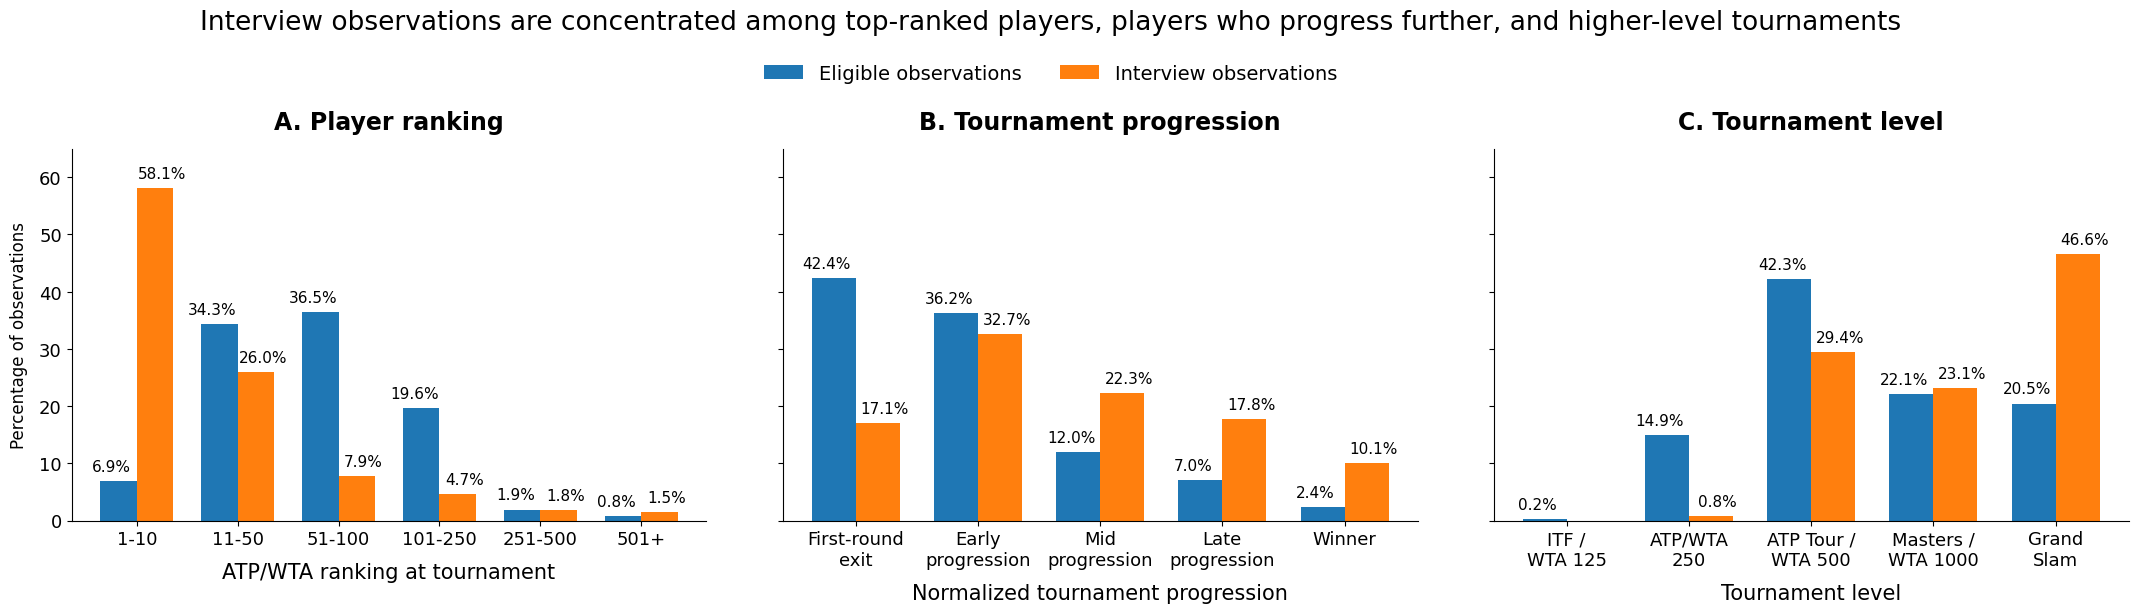

In [7]:
# ============================================================
# VISUALIZATION SETTINGS
# ============================================================

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
})

def add_bar_labels(ax, bars, horizontal_offset=0):

    for bar in bars:
        height = bar.get_height()

        if height > 0:
            ax.annotate(
                f"{height:.1f}%",
                xy=(
                    bar.get_x() + bar.get_width() / 2,
                    height
                ),
                xytext=(horizontal_offset, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=11
            )

def grouped_percentage_bars(
    ax,
    categories,
    eligible_values,
    interview_values,
    title,
    xlabel
):
    x = np.arange(len(categories))
    width = 0.36

    bars_eligible = ax.bar(
        x - width / 2,
        eligible_values,
        width,
        label="Eligible observations"
    )

    bars_interview = ax.bar(
        x + width / 2,
        interview_values,
        width,
        label="Interview observations"
    )

    add_bar_labels(
        ax,
        bars_eligible,
        horizontal_offset=-5
    )

    add_bar_labels(
        ax,
        bars_interview,
        horizontal_offset=5
    )

    ax.set_xticks(x)
    ax.set_xticklabels(categories)

    ax.set_xlabel(
        xlabel,
        fontsize=15,
        labelpad=10
    )

    ax.set_title(
        title,
        fontsize=17,
        fontweight="bold",
        pad=14
    )

    ax.tick_params(
        axis="both",
        labelsize=13
    )

    axes[0].set_ylabel(
        "Percentage of observations",
        fontsize=15,
        labelpad=10
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return bars_eligible, bars_interview


# ============================================================
# A. PLAYER RANKING
# ============================================================

rank_bins = [
    0,
    10,
    50,
    100,
    250,
    500,
    np.inf
]

rank_labels = [
    "1-10",
    "11-50",
    "51-100",
    "101-250",
    "251-500",
    "501+"
]


def get_rank_distribution(df):

    ranks = pd.to_numeric(
        df["player_rank"],
        errors="coerce"
    )

    ranks = ranks[ranks > 0]

    groups = pd.cut(
        ranks,
        bins=rank_bins,
        labels=rank_labels,
        include_lowest=True
    )

    return (
        groups
        .value_counts(normalize=True)
        .reindex(rank_labels, fill_value=0)
        .mul(100)
    )


eligible_rank = get_rank_distribution(
    population_df
)

interview_rank = get_rank_distribution(
    interviews_df
)


# ============================================================
# B. TOURNAMENT PROGRESSION
# ============================================================

progression_labels = [
    "First-round\nexit",
    "Early\nprogression",
    "Mid\nprogression",
    "Late\nprogression",
    "Winner"
]

def progression_category(score):

    if pd.isna(score):
        return np.nan

    if np.isclose(score, 0):
        return "First-round\nexit"

    if score < 0.4:
        return "Early\nprogression"

    if score < 0.6:
        return "Mid\nprogression"

    if score < 1:
        return "Late\nprogression"

    return "Winner"


def get_progression_distribution(df):

    groups = (
        df["tournament_finish_score"]
        .apply(progression_category)
    )

    return (
        groups
        .value_counts(normalize=True)
        .reindex(
            progression_labels,
            fill_value=0
        )
        .mul(100)
    )


eligible_progression = get_progression_distribution(
    population_df
)

interview_progression = get_progression_distribution(
    interviews_df
)


# ============================================================
# C. TOURNAMENT LEVEL
# ============================================================

level_order = [
    0,
    1,
    2,
    3,
    4
]

level_labels = [
    "ITF /\nWTA 125",
    "ATP/WTA\n250",
    "ATP Tour /\nWTA 500",
    "Masters /\nWTA 1000",
    "Grand\nSlam"
]


def get_level_distribution(df):

    return (
        df["tournament_level_score"]
        .value_counts(normalize=True)
        .reindex(
            level_order,
            fill_value=0
        )
        .mul(100)
    )


eligible_level = get_level_distribution(
    population_df
)

interview_level = get_level_distribution(
    interviews_df
)


# ============================================================
# MAIN FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 6.2),
    sharey=True
)

Y_MAX = 65


# ------------------------------------------------------------
# Panel A
# ------------------------------------------------------------

grouped_percentage_bars(
    axes[0],
    rank_labels,
    eligible_rank.values,
    interview_rank.values,
    title="A. Player ranking",
    xlabel="ATP/WTA ranking at tournament"
)


# ------------------------------------------------------------
# Panel B
# ------------------------------------------------------------

grouped_percentage_bars(
    axes[1],
    progression_labels,
    eligible_progression.values,
    interview_progression.values,
    title="B. Tournament progression",
    xlabel="Normalized tournament progression"
)


# ------------------------------------------------------------
# Panel C
# ------------------------------------------------------------

grouped_percentage_bars(
    axes[2],
    level_labels,
    eligible_level.values,
    interview_level.values,
    title="C. Tournament level",
    xlabel="Tournament level"
)


# ============================================================
# SHARED Y SCALE
# ============================================================

for ax in axes:

    ax.set_ylim(
        0,
        Y_MAX
    )

    ax.set_yticks(
        np.arange(
            0,
            Y_MAX + 1,
            10
        )
    )


axes[0].set_ylabel(
    "Percentage of observations",
    fontsize=12,
    labelpad=8
)

axes[1].set_ylabel("")
axes[2].set_ylabel("")


# ============================================================
# SHARED LEGEND
# ============================================================

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

for ax in axes:
    legend = ax.get_legend()

    if legend is not None:
        legend.remove()


fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=2,
    frameon=False,
    fontsize=14
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "Interview observations are concentrated among top-ranked players, "
    "players who progress further, and higher-level tournaments",
    fontsize=19,
    y=0.995
)


# ============================================================
# SPACING
# ============================================================

plt.subplots_adjust(
    left=0.055,
    right=0.99,
    top=0.77,
    bottom=0.17,
    wspace=0.12
)

plt.show()